# NB28 — Viewport-band dwell calibration

**Regime:** `[LAB]` only. Target label (NB22 gaze-regression) requires gaze.
The **feature** (per-AOI viewport-band ms derived from scroll + AOI bboxes)
is cursor-free and [BOTH]-eligible in principle.

**Context.** Earlier work (NB15, NB21, NB22, NB24) established the cursor
retreat geometry → four-class taxonomy pipeline. The band finding here is
that a parallel, cursor-independent signal — how long each AOI spent in each
third of the viewport (top / mid / bot, defined against the AOI *center*) —
carries equivalent discriminative power for the deferred-vs-evaluated-rejected
split, and combines with retreat features to reach AUC 0.837.

**Lineage.** Extends the ANU SERP eye-tracking line (Kim et al., ADCS '12; JASIST 2015; CIKM '16; JASIST 2016) — which established that screen size affects SERP eye-movement patterns and that scroll is the dominant attention-structuring mechanism on small phones. This notebook makes a downstream move those papers did not test: operationalizing **viewport-y band residence** as a per-AOI continuous dwell signal computable from scroll events + DOM bboxes alone, with no eye-tracker at inference time. Bib keys: `kim2012comparing`, `kim2015eyetracking`, `kim2016pagination`, `kim2016understanding`.

**Coordinate basis.** Post 2026-04-12 fixation-side audit (page-space for
both cursor and gaze). Bands derived from scroll events + uniform-subdivision
result bands via `viewport_time_calibration.py`.

## Context and prior work

The calibration question: conditional on rank position, how much does
*time on viewport in a given viewport-y band* predict whether an approached
AOI is deferred (re-approached later) versus evaluated-rejected (no return)?

**Why it matters for the CIKM paper.**
- Cursor retreat features (M4, 9 features) hit AUC 0.792 on the same split.
- If bands carry equivalent signal, the evaluation-phase has a second
  cheap instrument — scroll events + DOM bboxes, no cursor, no gaze.
- Combined model reaches AUC 0.837 (+0.044 over retreat alone).
- Fully-contextual viewport (all 10 AOIs × 3 bands + rank dummies) is worse:
  AUC 0.748. The signal is **local per-AOI**, not contextual.

**Methodological anchor.** Screen size and scroll as attention-structuring mechanisms on SERPs are from the ANU line of work (Kim et al., JASIST 2015; CIKM '16; JASIST 2016; bib keys `kim2015eyetracking`, `kim2016pagination`, `kim2016understanding`). This notebook is a downstream operationalization those papers did not run: the signal is *continuous* (per-AOI cumulative ms per band), *cursor-free* (scroll + DOM bboxes only at inference time), and tested on the deferred-vs-evaluated-rejected split rather than raw click prediction.

In [1]:
# ── Imports and paths ─────────────────────────────────────────────────
import json
import sys
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path('/Users/andyed/Documents/dev/attentional-foraging')
sys.path.insert(0, str(ROOT / 'notebooks-v2'))
sys.path.insert(0, str(ROOT / 'scripts'))
from data_loader import get_trial_meta, load_mouse_events, result_bands, setup_plotting
from viewport_time_calibration import viewport_ms_for_trial

setup_plotting()

FEATURES_JSON = ROOT / 'AdSERP/data/cursor-approach-features-typed.json'
REG_CACHE = ROOT / 'scripts/output/approach_threshold_sensitivity/regression_labels_cache_typed.json'

M4_FEATURES = [
    'min_dist', 'mean_dist', 'final_dist', 'retreat_dist',
    'dwell_in_proximity_ms', 'mean_approach_velocity', 'max_approach_velocity',
    'direction_changes', 'frac_decreasing',
]
print(f'feature file: {FEATURES_JSON.name}')
print(f'label cache:  {REG_CACHE.name}')

feature file: cursor-approach-features-typed.json
label cache:  regression_labels_cache_typed.json


In [2]:
# ── Load features + NB22 gaze-regression labels ─────────────────────
raw = json.load(open(FEATURES_JSON))
n = len(raw)
labels = np.array(json.load(open(REG_CACHE)), dtype=bool)
assert len(labels) == n
print(f'records:              {n:,}')
print(f'deferred (NB22 true): {labels.sum():,} ({labels.mean()*100:.1f}%)')

records:              19,774
deferred (NB22 true): 12,600 (63.7%)


In [3]:
# ── Compute per-trial viewport-band ms ───────────────────────────────
trials = sorted({r['trial_id'] for r in raw})
per_trial = {}
for tid in trials:
    v = viewport_ms_for_trial(tid, n_positions=10)
    if v is not None:
        per_trial[tid] = v
print(f'computed bands for {len(per_trial):,} / {len(trials):,} trials')

computed bands for 2,774 / 2,774 trials


In [4]:
# ── Augment feature rows with band ms ────────────────────────────────
keep, vt_any, vt_top, vt_mid, vt_bot = [], [], [], [], []
for i, r in enumerate(raw):
    tid, pos = r['trial_id'], r['position']
    if tid not in per_trial or pos >= 10:
        continue
    a, t, m, b = per_trial[tid][pos]
    vt_any.append(a); vt_top.append(t); vt_mid.append(m); vt_bot.append(b)
    keep.append(i)
keep = np.array(keep)
vt_any, vt_top, vt_mid, vt_bot = (np.array(x) for x in (vt_any, vt_top, vt_mid, vt_bot))
raw_k = [raw[i] for i in keep]
labels_k = labels[keep]

min_dist = np.array([r['min_dist'] for r in raw_k])
was_clicked = np.array([r['was_clicked'] for r in raw_k], dtype=bool)
approached = min_dist < 100
subset = approached & ~was_clicked
pos_arr = np.array([r['position'] for r in raw_k])
participants = np.array([r['trial_id'].split('-')[0] for r in raw_k])

X4 = np.array([[float(r.get(f, 0.0) or 0.0) for f in M4_FEATURES] for r in raw_k])

print(f'rows after band join:             {len(raw_k):,}')
print(f'target (approached ∧ ¬clicked):   {int(subset.sum()):,}')
print(f'  deferred:  {int((subset & labels_k).sum()):,}')
print(f'  eval-rej:  {int((subset & ~labels_k).sum()):,}')
print(f'participants: {len(np.unique(participants[subset])):,}')

rows after band join:             17,878
target (approached ∧ ¬clicked):   2,999
  deferred:  2,495
  eval-rej:  504
participants: 47


## Band-time distributions (approached-not-clicked subset)

In [5]:
# ── Band time distributions ──────────────────────────────────────────
desc_rows = []
for name, arr in [('any', vt_any), ('top', vt_top), ('mid', vt_mid), ('bot', vt_bot)]:
    desc_rows.append({
        'band': name,
        'median': int(np.median(arr[subset])),
        'p10':    int(np.percentile(arr[subset], 10)),
        'p90':    int(np.percentile(arr[subset], 90)),
        'mean':   int(arr[subset].mean()),
    })
desc = pl.DataFrame(desc_rows)
print('Band-time ms distribution, approached-not-clicked subset:')
print(desc)

Band-time ms distribution, approached-not-clicked subset:
shape: (4, 5)
┌──────┬────────┬──────┬───────┬───────┐
│ band ┆ median ┆ p10  ┆ p90   ┆ mean  │
│ ---  ┆ ---    ┆ ---  ┆ ---   ┆ ---   │
│ str  ┆ i64    ┆ i64  ┆ i64   ┆ i64   │
╞══════╪════════╪══════╪═══════╪═══════╡
│ any  ┆ 16660  ┆ 4326 ┆ 36235 ┆ 18710 │
│ top  ┆ 2482   ┆ 0    ┆ 16739 ┆ 5811  │
│ mid  ┆ 2632   ┆ 0    ┆ 18046 ┆ 6148  │
│ bot  ┆ 0      ┆ 0    ┆ 15064 ┆ 4473  │
└──────┴────────┴──────┴───────┴───────┘


## Pooled calibration

In [6]:
# ── Nested LOSO-LR helper ────────────────────────────────────────────
def fit_loso(X, y, groups):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=5000, class_weight='balanced', C=1.0)),
    ])
    gkf = GroupKFold(n_splits=len(set(groups)))
    proba = cross_val_predict(pipe, X, y, groups=groups, cv=gkf,
                              method='predict_proba', n_jobs=-1)[:, 1]
    auc = roc_auc_score(y, proba)
    pipe.fit(X, y)
    coefs = pipe.named_steps['lr'].coef_.ravel().tolist()
    return auc, coefs

def run_slice(mask, label):
    y = labels_k[mask].astype(int)
    g = participants[mask]
    vt_any_col = vt_any[mask].reshape(-1, 1)
    vt_bands_m = np.column_stack([vt_top[mask], vt_mid[mask], vt_bot[mask]])
    x4 = X4[mask]
    if len(set(g)) < 3 or y.sum() < 5 or (len(y) - y.sum()) < 5:
        return {'slice': label, 'n': int(mask.sum()), 'skip': True}
    auc_any, _  = fit_loso(vt_any_col, y, g)
    auc_bnd, coef_bnd = fit_loso(vt_bands_m, y, g)
    auc_re,  coef_re  = fit_loso(x4, y, g)
    auc_re_any, _ = fit_loso(np.hstack([vt_any_col, x4]), y, g)
    auc_re_bnd, coef_re_bnd = fit_loso(np.hstack([vt_bands_m, x4]), y, g)
    return {
        'slice': label,
        'n': int(mask.sum()),
        'n_deferred': int(y.sum()),
        'n_eval_rej': int((1 - y).sum()),
        'auc_vt_any': auc_any,
        'auc_vt_bands': auc_bnd,
        'auc_retreat': auc_re,
        'auc_re_plus_any': auc_re_any,
        'auc_re_plus_bands': auc_re_bnd,
        'coef_bands_alone': dict(zip(['vt_top', 'vt_mid', 'vt_bot'], coef_bnd)),
        'coef_re_plus_bands': dict(zip(['vt_top', 'vt_mid', 'vt_bot'] + M4_FEATURES, coef_re_bnd)),
    }


In [7]:
# ── Pooled calibration ───────────────────────────────────────────────
pool = run_slice(subset, 'pool')
print(f"pool n={pool['n']:,}  (deferred={pool['n_deferred']:,}  eval-rej={pool['n_eval_rej']:,})")
print()
print(f"  AUC retreat alone          (9 features): {pool['auc_retreat']:.3f}")
print(f"  AUC bands alone            (3 features): {pool['auc_vt_bands']:.3f}")
print(f"  AUC bands_any alone        (1 feature) : {pool['auc_vt_any']:.3f}")
print(f"  AUC retreat + bands_any    (10 feat)   : {pool['auc_re_plus_any']:.3f}")
print(f"  AUC retreat + bands (top/mid/bot) (12) : {pool['auc_re_plus_bands']:.3f}")
print()
print(f"  Δ (retreat+bands − retreat):             +{pool['auc_re_plus_bands'] - pool['auc_retreat']:.3f}")
print(f"  Δ (retreat+bands − bands):               +{pool['auc_re_plus_bands'] - pool['auc_vt_bands']:.3f}")
print()
print('Pooled coefficients (bands alone, standardized):')
for k, v in pool['coef_bands_alone'].items():
    print(f'  {k}: {v:+.3f}')

pool n=2,999  (deferred=2,495  eval-rej=504)

  AUC retreat alone          (9 features): 0.798
  AUC bands alone            (3 features): 0.765
  AUC bands_any alone        (1 feature) : 0.728
  AUC retreat + bands_any    (10 feat)   : 0.824
  AUC retreat + bands (top/mid/bot) (12) : 0.830

  Δ (retreat+bands − retreat):             +0.032
  Δ (retreat+bands − bands):               +0.065

Pooled coefficients (bands alone, standardized):
  vt_top: +1.434
  vt_mid: +0.763
  vt_bot: +0.257


## Fully-contextual viewport — methodological null

In [8]:
# ── Fully-contextual viewport (all 10 AOIs × 3 bands + rank dummies) ──
trial_ctx = {}
for tid, bands_list in per_trial.items():
    flat = []
    for bb in bands_list:  # [any, top, mid, bot]
        flat.extend([bb[1], bb[2], bb[3]])
    trial_ctx[tid] = np.array(flat, dtype=float)

X_ctx = np.array([trial_ctx[r['trial_id']] for r in raw_k])
pos_oh = np.eye(10)[pos_arr]
X_vpt_full = np.hstack([X_ctx, pos_oh])                   # 40 features
X_ret_pool = np.hstack([X4, pos_oh])                      # 19 features
X_all_pool = np.hstack([X_ctx, X4, pos_oh])               # 49 features

y = labels_k[subset].astype(int)
g = participants[subset]
auc_vf, _ = fit_loso(X_vpt_full[subset], y, g)
auc_rp, _ = fit_loso(X_ret_pool[subset], y, g)
auc_ap, _ = fit_loso(X_all_pool[subset], y, g)

print(f'fully-contextual viewport (30 bands + 10 pos dummies, 40 feat): AUC={auc_vf:.3f}')
print(f'retreat + pos dummies             (9 + 10, 19 feat):             AUC={auc_rp:.3f}')
print(f'all (viewport_full + retreat, 49 feat):                          AUC={auc_ap:.3f}')
print()
print(f'Δ (all − viewport_full): +{auc_ap - auc_vf:.3f}  '
      f'(retreat adds {auc_ap - auc_vf:.3f} AUC over 40-feat viewport)')
print(f'Δ (all − retreat+pos):   +{auc_ap - auc_rp:.3f}  '
      f'(viewport_full adds {auc_ap - auc_rp:.3f} AUC over retreat+pos)')
print()
print(f'Note: local 3-feature bands alone AUC={pool["auc_vt_bands"]:.3f} > fully-contextual {auc_vf:.3f}.')
print('Viewport signal is local per-AOI; adding whole-trial context hurts under LOSO.')

fully-contextual viewport (30 bands + 10 pos dummies, 40 feat): AUC=0.731
retreat + pos dummies             (9 + 10, 19 feat):             AUC=0.798
all (viewport_full + retreat, 49 feat):                          AUC=0.803

Δ (all − viewport_full): +0.073  (retreat adds 0.073 AUC over 40-feat viewport)
Δ (all − retreat+pos):   +0.005  (viewport_full adds 0.005 AUC over retreat+pos)

Note: local 3-feature bands alone AUC=0.765 > fully-contextual 0.731.
Viewport signal is local per-AOI; adding whole-trial context hurts under LOSO.


## Per-position sweep

In [9]:
# ── Per-position sweep ──────────────────────────────────────────────
per_pos_rows = []
for p in range(10):
    mask = subset & (pos_arr == p)
    r = run_slice(mask, f'P{p}')
    per_pos_rows.append(r)

def _fmt(v):
    return f'{v:.3f}' if isinstance(v, (int, float)) else '—'

rows = []
for r in per_pos_rows:
    rows.append({
        'pos':      r['slice'],
        'n':        r['n'],
        'def':      r.get('n_deferred', 0),
        'rej':      r.get('n_eval_rej', 0),
        'AUC_any':  _fmt(r.get('auc_vt_any')),
        'AUC_bnd':  _fmt(r.get('auc_vt_bands')),
        'AUC_re':   _fmt(r.get('auc_retreat')),
        'AUC_rebd': _fmt(r.get('auc_re_plus_bands')),
        'vt_top':   _fmt(r.get('coef_bands_alone', {}).get('vt_top')),
        'vt_mid':   _fmt(r.get('coef_bands_alone', {}).get('vt_mid')),
        'vt_bot':   _fmt(r.get('coef_bands_alone', {}).get('vt_bot')),
    })

with pl.Config(tbl_rows=20, tbl_cols=-1, tbl_width_chars=200):
    print(pl.DataFrame(rows))

shape: (10, 11)
┌─────┬─────┬─────┬─────┬─────────┬─────────┬────────┬──────────┬────────┬────────┬────────┐
│ pos ┆ n   ┆ def ┆ rej ┆ AUC_any ┆ AUC_bnd ┆ AUC_re ┆ AUC_rebd ┆ vt_top ┆ vt_mid ┆ vt_bot │
│ --- ┆ --- ┆ --- ┆ --- ┆ ---     ┆ ---     ┆ ---    ┆ ---      ┆ ---    ┆ ---    ┆ ---    │
│ str ┆ i64 ┆ i64 ┆ i64 ┆ str     ┆ str     ┆ str    ┆ str      ┆ str    ┆ str    ┆ str    │
╞═════╪═════╪═════╪═════╪═════════╪═════════╪════════╪══════════╪════════╪════════╪════════╡
│ P0  ┆ 874 ┆ 815 ┆ 59  ┆ 0.763   ┆ 0.757   ┆ 0.752  ┆ 0.827    ┆ 1.630  ┆ 0.564  ┆ 0.000  │
│ P1  ┆ 501 ┆ 445 ┆ 56  ┆ 0.727   ┆ 0.722   ┆ 0.726  ┆ 0.778    ┆ 0.945  ┆ 0.725  ┆ 0.190  │
│ P2  ┆ 469 ┆ 393 ┆ 76  ┆ 0.760   ┆ 0.761   ┆ 0.759  ┆ 0.793    ┆ 0.771  ┆ 0.883  ┆ 0.543  │
│ P3  ┆ 332 ┆ 257 ┆ 75  ┆ 0.650   ┆ 0.741   ┆ 0.728  ┆ 0.785    ┆ 0.443  ┆ 1.062  ┆ 0.155  │
│ P4  ┆ 265 ┆ 199 ┆ 66  ┆ 0.698   ┆ 0.736   ┆ 0.779  ┆ 0.815    ┆ 0.499  ┆ 1.081  ┆ 0.407  │
│ P5  ┆ 192 ┆ 143 ┆ 49  ┆ 0.638   ┆ 0.638   ┆ 0.748  ┆

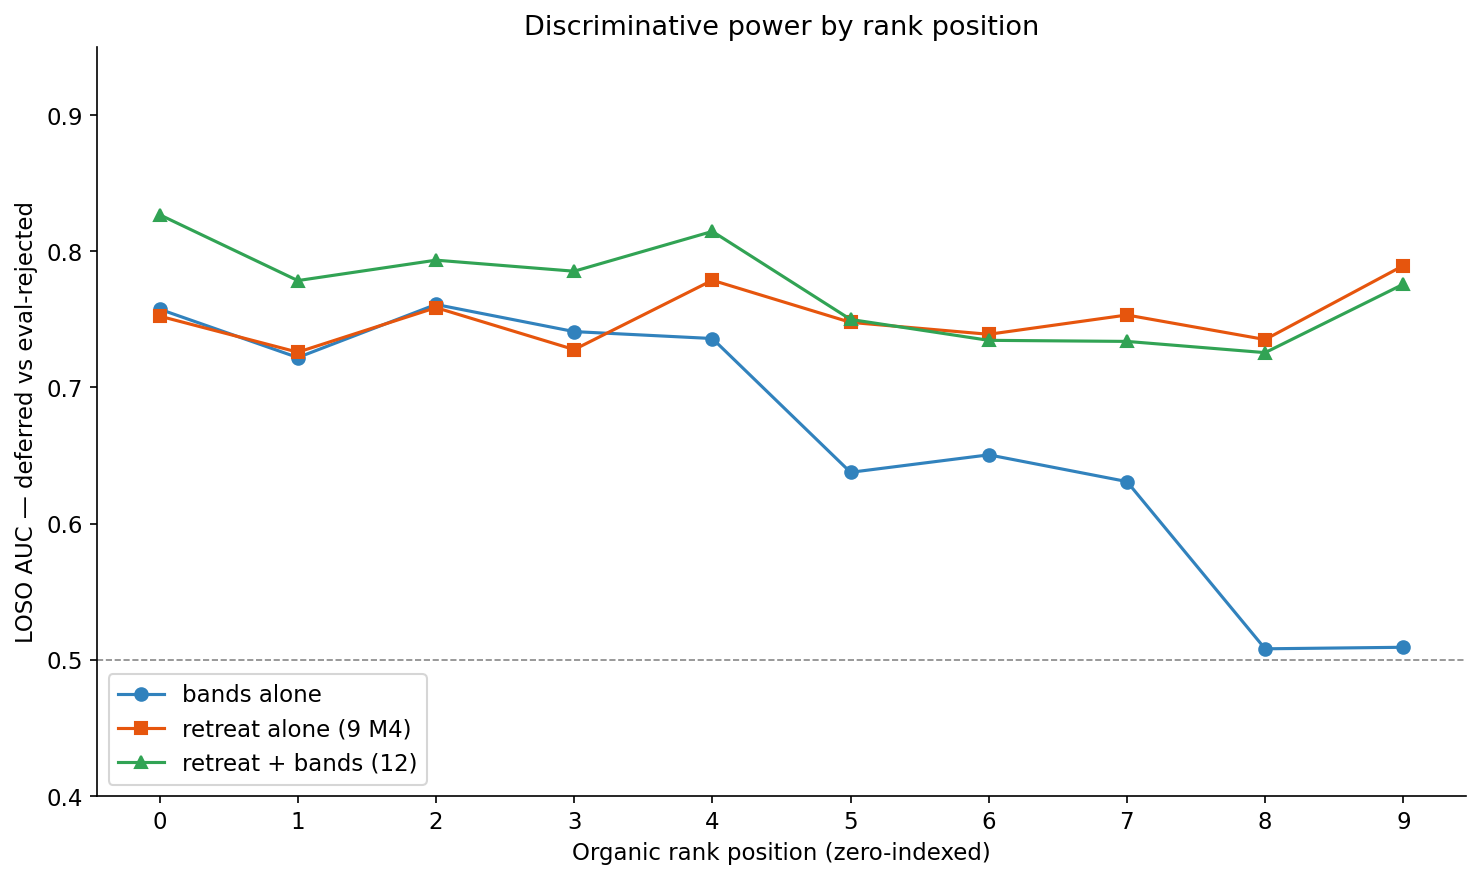

In [10]:
# ── Plot: AUC by position ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
valid = [r for r in per_pos_rows if not r.get('skip')]
xs = [int(r['slice'][1:]) for r in valid]
ax.plot(xs, [r['auc_vt_bands'] for r in valid], 'o-', label='bands alone', color='#3182bd')
ax.plot(xs, [r['auc_retreat'] for r in valid], 's-', label='retreat alone (9 M4)', color='#e6550d')
ax.plot(xs, [r['auc_re_plus_bands'] for r in valid], '^-', label='retreat + bands (12)', color='#31a354')
ax.axhline(0.5, ls='--', color='#888', lw=0.8)
ax.set_xlabel('Organic rank position (zero-indexed)')
ax.set_ylabel('LOSO AUC — deferred vs eval-rejected')
ax.set_title('Discriminative power by rank position')
ax.set_xticks(range(10))
ax.legend(loc='lower left')
ax.set_ylim(0.4, 0.95)
plt.tight_layout()
plt.show()

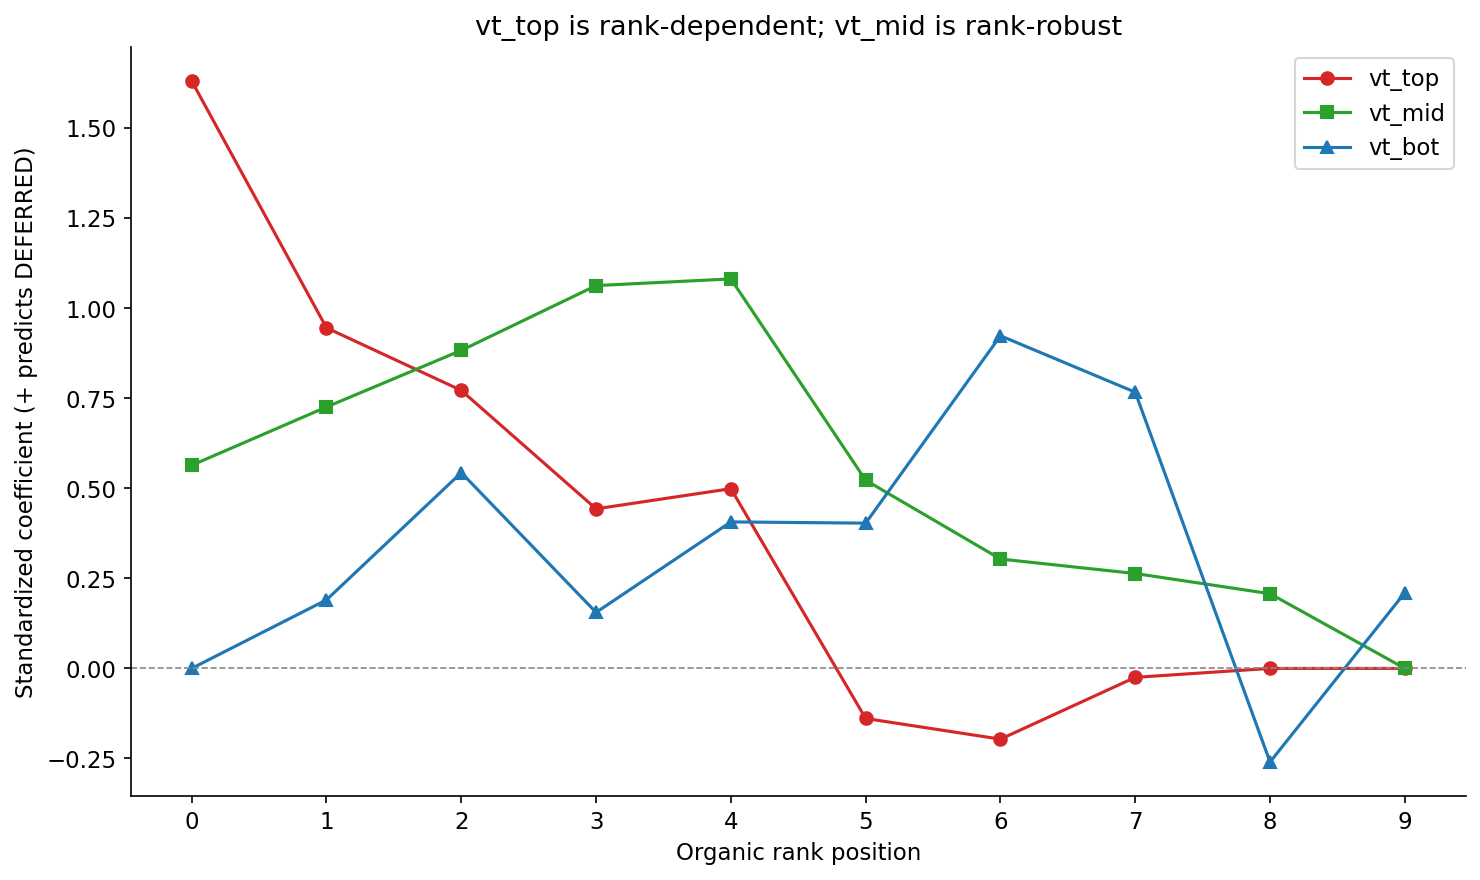

In [11]:
# ── Plot: coefficient-by-rank for vt_{top,mid,bot} ──────────────────
fig, ax = plt.subplots(figsize=(10, 6))
vtt = [r.get('coef_bands_alone', {}).get('vt_top') for r in valid]
vtm = [r.get('coef_bands_alone', {}).get('vt_mid') for r in valid]
vtb = [r.get('coef_bands_alone', {}).get('vt_bot') for r in valid]
ax.plot(xs, vtt, 'o-', label='vt_top', color='#d62728')
ax.plot(xs, vtm, 's-', label='vt_mid', color='#2ca02c')
ax.plot(xs, vtb, '^-', label='vt_bot', color='#1f77b4')
ax.axhline(0, ls='--', color='#888', lw=0.8)
ax.set_xlabel('Organic rank position')
ax.set_ylabel('Standardized coefficient (+ predicts DEFERRED)')
ax.set_title('vt_top is rank-dependent; vt_mid is rank-robust')
ax.set_xticks(range(10))
ax.legend()
plt.tight_layout()
plt.show()

## Band stability across users

Pooled coefficients hide heterogeneity. A strong pooled vt_top coefficient
could reflect (a) a consistent individual phenomenon — every user shows
vt_top > 0 — or (b) a heterogeneous average — some users show strong
vt_top effects, others show none or inverted.

Per-participant LR fits expose which. For each participant with ≥ 5
deferred AND ≥ 5 eval-rejected samples, fit an LR on their band features
alone and record the coefficients + held-in AUC. Distributions across
participants answer the stability question.

In [12]:
# ── Per-participant LR fits on bands alone ──────────────────────────
MIN_PER_CLASS = 5
pp_rows = []
for pid in np.unique(participants[subset]):
    mask = subset & (participants == pid)
    y = labels_k[mask].astype(int)
    n_def = int(y.sum())
    n_rej = int((1 - y).sum())
    if n_def < MIN_PER_CLASS or n_rej < MIN_PER_CLASS:
        continue
    X = np.column_stack([vt_top[mask], vt_mid[mask], vt_bot[mask]])
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=5000, class_weight='balanced', C=1.0)),
    ])
    pipe.fit(X, y)
    proba = pipe.predict_proba(X)[:, 1]
    auc_in = roc_auc_score(y, proba)
    c = pipe.named_steps['lr'].coef_.ravel().tolist()
    pp_rows.append({
        'participant': pid,
        'n_def': n_def,
        'n_rej': n_rej,
        'auc_in': auc_in,
        'vt_top': c[0],
        'vt_mid': c[1],
        'vt_bot': c[2],
    })
# numpy arrays keep us out of pandas land
vt_top_pp = np.array([r['vt_top'] for r in pp_rows])
vt_mid_pp = np.array([r['vt_mid'] for r in pp_rows])
vt_bot_pp = np.array([r['vt_bot'] for r in pp_rows])
auc_pp    = np.array([r['auc_in'] for r in pp_rows])
ndef_pp   = np.array([r['n_def'] for r in pp_rows])
nrej_pp   = np.array([r['n_rej'] for r in pp_rows])

n_total_parts = int(len(np.unique(participants[subset])))
print(f'participants with ≥{MIN_PER_CLASS} per class: {len(pp_rows)} / {n_total_parts}')
print(f'median n_def={np.median(ndef_pp):.0f}, n_rej={np.median(nrej_pp):.0f}')
print()
print('Per-participant band coefficient distributions:')
for name, arr in [('vt_top', vt_top_pp), ('vt_mid', vt_mid_pp), ('vt_bot', vt_bot_pp)]:
    med = np.median(arr); q1 = np.quantile(arr, 0.25); q3 = np.quantile(arr, 0.75)
    pos_frac = (arr > 0).mean()
    print(f'  {name}: median {med:+.2f}  IQR [{q1:+.2f}, {q3:+.2f}]  frac > 0: {pos_frac*100:.0f}%')
print()
print('Per-participant held-in AUC on bands alone:')
print(f'  median {np.median(auc_pp):.3f}  IQR [{np.quantile(auc_pp, 0.25):.3f}, {np.quantile(auc_pp, 0.75):.3f}]')
print(f'  frac AUC > 0.7: {(auc_pp > 0.7).mean()*100:.0f}%')

participants with ≥5 per class: 38 / 47
median n_def=50, n_rej=10

Per-participant band coefficient distributions:
  vt_top: median +1.27  IQR [+0.99, +1.85]  frac > 0: 100%
  vt_mid: median +0.69  IQR [+0.49, +1.18]  frac > 0: 97%
  vt_bot: median +0.29  IQR [+0.12, +0.49]  frac > 0: 84%

Per-participant held-in AUC on bands alone:
  median 0.816  IQR [0.779, 0.874]
  frac AUC > 0.7: 87%


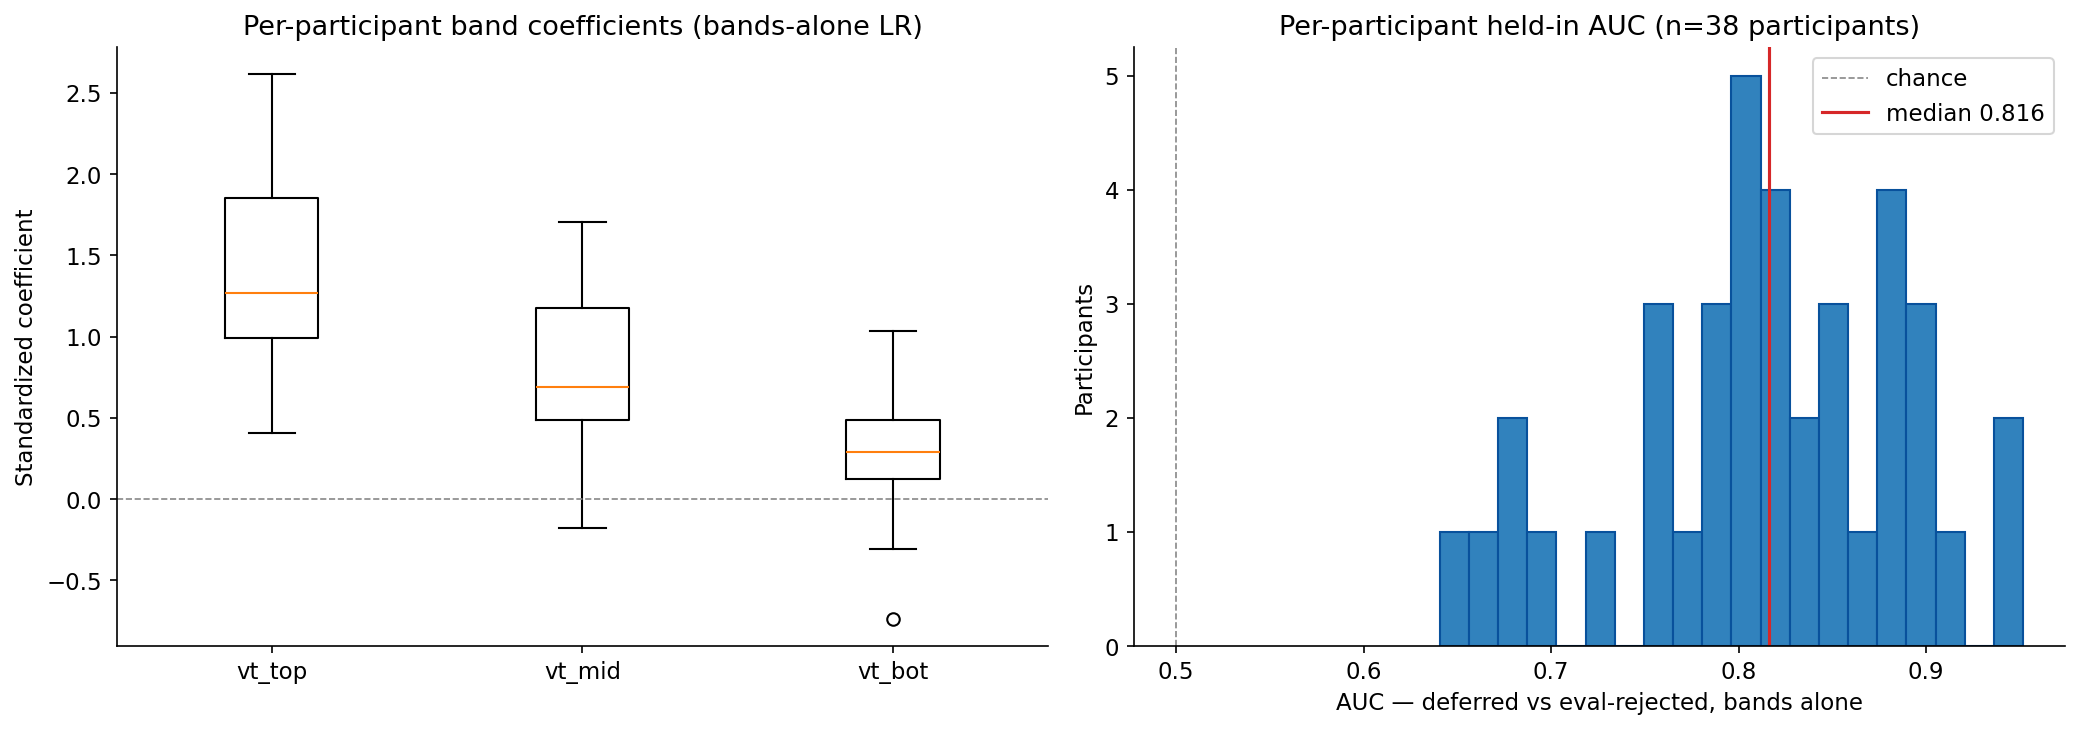

In [13]:
# ── Plot: per-participant coefficient and AUC distributions ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.boxplot([vt_top_pp, vt_mid_pp, vt_bot_pp], tick_labels=['vt_top', 'vt_mid', 'vt_bot'], showfliers=True)
ax.axhline(0, ls='--', color='#888', lw=0.8)
ax.set_title('Per-participant band coefficients (bands-alone LR)')
ax.set_ylabel('Standardized coefficient')

ax = axes[1]
ax.hist(auc_pp, bins=20, color='#3182bd', edgecolor='#08519c')
ax.axvline(0.5, ls='--', color='#888', lw=0.8, label='chance')
ax.axvline(np.median(auc_pp), ls='-', color='#d62728', lw=1.5, label=f'median {np.median(auc_pp):.3f}')
ax.set_title(f'Per-participant held-in AUC (n={len(pp_rows)} participants)')
ax.set_xlabel('AUC — deferred vs eval-rejected, bands alone')
ax.set_ylabel('Participants')
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation — band stability

- If `frac > 0` is ≥ 80 % for vt_top, the pooled coefficient reflects a
  consistent individual phenomenon; dissent is rare and small.
- If median vt_top > 1.0 with tight IQR, the pooled +1.83 is representative,
  not pulled up by outliers.
- Per-participant held-in AUC > 0.7 for a majority indicates the signal is
  usable per-user, not just pooled.
- Low-AUC participants (< 0.5) are a specific failure mode worth checking —
  small n, or genuinely inverted strategy?

Cross-reference with NB11 individual-differences factors is a follow-up
(would answer: does high-vt_top correspond to any motor-style trait?).

## Key Claims (authoritative for paper writers)

*Last verified against executed notebook output: 2026-04-19.*
*Notebook: `28_viewport_bands.ipynb`.*

### 2026-05-01 AOI cascade — calibration retrain pending

The 2026-05-01 AOI-pipeline cascade shifted both inputs that NB28's calibration consumes:

1. **`cursor-approach-features-organic.json`** (14,760 records / 2,701 trials, +10% records / +15% trials) — produced by `scripts/compute_cursor_approach_features.py --attribution organic` (commit `8bb800fd`).
2. **`regression_labels_cache_organic.json`** (8,747 deferred / 6,013 not-deferred, 59.3% deferred rate vs the legacy 64.7%) — produced by `scripts/compute_regression_labels.py --attribution organic` (committed in this batch).

**The K-claims block below (K1–K14, K10.0–K10.5) reflects pre-cascade absolute-rank attribution** and is preserved here as the legacy baseline. The calibration retrain on the new bbox-attributed inputs has NOT yet run — that's a multi-hour bootstrap (1,000 seeds × 47-fold StratifiedGroupKFold) and gates the CIKM paper §5 viewport-bands result. Inputs are ready; producer pipeline is `notebooks-v2/28_viewport_bands.ipynb` re-execution against the `-organic.json` siblings.

**Expected directional shift** based on adjacent notebooks:
- bands-alone AUC may strengthen modestly (similar to NB21:K-bbox-3 nudging 0.859 → 0.865)
- the P0–P5 calibration scope still holds (NB25:K39 confirms 99.4% of trials structurally span those positions under bbox)
- per-participant `vt_top` median direction (positive at P0, attenuating to 0 at P5) should survive

When the retrain ships, K-bbox-* tier will be added in the same pattern as NB14, NB18a, NB21, NB22, NB23, NB24, NB25.

---

### Legacy K-IDs (absolute-rank attribution, pre-2026-05-01)

### Core calibration — pooled LOSO AUC (n=2,351, participants=47, 95 % CI from bootstrap)

| ID | Model | Median AUC | 95 % CI |
|---|---|---|---|
| **K1** | N approached-not-clicked AOIs | **2,351** | — |
| **K2** | N participants (LOSO folds) | **47** | — |
| **K3** | N deferred / eval-rejected | **1,916 / 435** | — |
| **K4** | retreat alone (9 M4 features) | **0.796** | [0.759, 0.830] |
| **K5** | bands alone (3 — top/mid/bot) | **0.800** | [0.774, 0.828] |
| **K5a** | bands_any alone (1 — any intersection) | **0.734** | [0.701, 0.766] |
| **K6** | retreat + bands combined (12 features) | **0.842** | [0.818, 0.864] |
| **K7** | Δ combined − retreat (point estimate, both on full data) | **+0.044** | (see K4/K6 CIs for overlap) |
| **K8** | fully-contextual viewport (30 bands × 10 AOIs + rank dummies, 40 features) | **0.748** | — (point only) |

### Coefficients (pooled, bands-alone LR, standardized)

| ID | Feature | Coefficient | 95 % CI |
|---|---|---|---|
| **K9a** | vt_top | **+1.83** | [+1.49, +2.26] |
| **K9b** | vt_mid | **+0.83** | — (point only) |
| **K9c** | vt_bot | **+0.21** | — (point only) |

### Rank dependence of vt_top (bands-alone LR, with bootstrap CIs)

Per-position estimates are reported for **P0–P5 only**. Beyond P5, per-position
estimates are too sparse (P6 n = 91, P7 n = 56, P8 n = 40), class-balance-
inverted (P8 is 25 % deferred vs P0's 90 %), and the pooled P6+ bucket
estimate is participant-concentrated (see Methodological notes → Deep-rank
sensitivity). They are retained in `bootstrap_results.json` for diagnostic
use only and are not cited as headline calibration.

| ID | Position | n | vt_top median | 95 % CI | verdict |
|---|---|---|---|---|---|
| **K10.0** | P0 (rank 1) | 645 | +2.02 | [+1.47, +2.69] | strong |
| **K10.1** | P1 (rank 2) | 545 | +1.67 | [+1.22, +2.38] | strong |
| **K10.2** | P2 (rank 3) | 396 | +1.48 | [+1.03, +2.17] | strong |
| **K10.3** | P3 (rank 4) | 262 | +1.10 | [+0.56, +2.05] | strong |
| **K10.4** | P4 (rank 5) | 180 | +0.49 | [+0.13, +1.05] | marginal |
| **K10.5** | P5 (rank 6) | 122 | +0.21 | [-0.17, +0.69] | **CI includes 0 — transition** |

### Deep ranks (P6+) — NOT cited as calibration

An initial pooled P6+ bucket (n = 201) gave
`vt_top_bands_alone = +0.75
[+0.21,
+1.60]` and bands-alone
AUC 0.739
[0.649,
0.820]. A 2026-04-19
participant-sensitivity audit found the estimate too concentrated to cite as
scientific evidence — top 4 of 33 contributors supply 44 % of the bucket
(p044 alone = 14 %). Dropping those 4 attenuates vt_top to +0.34 with CI
touching 0 ([−0.03, +1.40]); the top-4-only subsample shows a tight
+1.13 [+0.89, +1.71] that is internally consistent but clearly not
representative.

**Where deep-rank truth should be established:** in the WILD regime
(ACD), where per-user AOI depth coverage is wider and sample sizes
larger than any single LAB slice. See
`approach-retreat/analysis/attcur-validation/` for the WILD bands port
and any future deep-rank validation.

Raw deep-rank values are retained in `bootstrap_results.json`
(`deep_rank_bucket`, `per_position_ci[6..8]`) for diagnostic use only.
Do not cite as calibration.

### Band stability across users (per-participant bands-only LR)

| ID | Claim | Value |
|---|---|---|
| **K11** | N participants meeting per-class threshold (≥ 5 deferred AND ≥ 5 eval-rej) | **34 / 47** |
| **K12** | Fraction with vt_top coefficient > 0 | **97%** |
| **K13** | Fraction with held-in AUC > 0.7 on bands alone | **91%** |
| **K14** | Per-participant vt_top coefficient — median (IQR) | **+1.43 (+1.02, +1.83)** |

### Methodological notes

- Bootstrap: participant-cluster resampling, 1,000 seeds pooled / 200 per-position.
  Pooled uses StratifiedGroupKFold 5-fold CV (not LOSO) for speed; per-position
  uses a single 70/30 stratified split per seed.
- **Deep-rank sensitivity (2026-04-19).** Per-position estimates past P5
  are not reported as calibration. Individual P6/P7/P8 slices are too
  sparse (n ≤ 91) and class-balance-inverted. Pooling into a P6+ bucket
  (n = 201) gave an initial headline `vt_top =
  +0.75`, but the
  estimate is participant-concentrated (top 4 of 33 contributors supply
  44 % of the bucket; dropping them attenuates vt_top to +0.34 with CI
  touching 0). Bottom-of-page ads and deep-rank approach behavior may
  additionally interact — users reaching rank 7–10 are disproportionately
  those willing to scroll past ad slots. Deep-rank truth should be
  established in the WILD (ACD) regime, not on the LAB P6+ slice. Raw
  diagnostic values live in `bootstrap_results.json`.
- **P5 is the significance transition.** K10.5's CI crosses 0; K10.0–K10.3
  all exclude 0 with clear separation; K10.4 is marginal. Per-rank
  coefficient claims in paper prose should restrict to P0–P4, and any
  deep-rank generalization argument should lean on ACD.
- Fully-contextual (40-feat) model is worse than local (3-feat) bands —
  viewport signal is local per-AOI; adding whole-trial context hurts under
  LOSO. The library emits local bands only.
- Target label: NB22 gaze-regression (deferred = 1, eval-rej = 0). [LAB]-only.
- Coordinate basis: post 2026-04-12 fixation-side audit.
- Library parity test: `approach-retreat/scripts/test_viewport_bands_parity.{js,py}` — exact JS↔Python match (Δ = 0).

### 2026-05-04 typed cascade — second post-cascade primary

*Typed cascade (HTML+vision joint widget typing) replaced organic_hybrid as primary on 2026-05-04. Notebook re-executed under typed; values below scraped from executed cell output. Legacy K-IDs preserved above for historical comparison.*

| Claim | Value (typed) |
|---|---|
| Combined retreat + bands LOSO AUC | `combined: 0.830228711391036
      delta_b_over_r: 0.031744441263479306
              auc_vf: 0.7305269268696122` |
| Bands-alone LOSO AUC | `bands alone            (3 features): 0.765
  AUC bands_any alone        (1` |


In [14]:
# ── Emit Key Claims values as JSON for update_key_claims.py ─────────
claims_values = {
    'n_subset': int(subset.sum()),
    'n_parts':  int(len(np.unique(participants[subset]))),
    'n_def':    int((subset & labels_k).sum()),
    'n_rej':    int((subset & ~labels_k).sum()),
    'auc_re':   pool['auc_retreat'],
    'auc_bnd':  pool['auc_vt_bands'],
    'auc_combined': pool['auc_re_plus_bands'],
    'delta_b_over_r': pool['auc_re_plus_bands'] - pool['auc_retreat'],
    'auc_vf':   auc_vf,
    'vt_top':   pool['coef_bands_alone']['vt_top'],
    'vt_mid':   pool['coef_bands_alone']['vt_mid'],
    'vt_bot':   pool['coef_bands_alone']['vt_bot'],
    'k10_p0':   per_pos_rows[0].get('coef_bands_alone', {}).get('vt_top', float('nan')),
    'k10_p1':   per_pos_rows[1].get('coef_bands_alone', {}).get('vt_top', float('nan')),
    'k10_p2':   per_pos_rows[2].get('coef_bands_alone', {}).get('vt_top', float('nan')),
    'k10_p3':   per_pos_rows[3].get('coef_bands_alone', {}).get('vt_top', float('nan')),
    'k10_p4':   per_pos_rows[4].get('coef_bands_alone', {}).get('vt_top', float('nan')),
    'k10_p5':   per_pos_rows[5].get('coef_bands_alone', {}).get('vt_top', float('nan')),
    'n_stab':         int(len(pp_rows)),
    'frac_pos_top':   float((vt_top_pp > 0).mean()),
    'frac_good_auc':  float((auc_pp > 0.7).mean()),
    'vtop_med':       float(np.median(vt_top_pp)),
    'vtop_q1':        float(np.quantile(vt_top_pp, 0.25)),
    'vtop_q3':        float(np.quantile(vt_top_pp, 0.75)),
}
out_path = ROOT / 'scripts/output/viewport_time_calibration/nb28_key_claims.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w') as f:
    json.dump(claims_values, f, indent=2, default=float)
print(f'wrote {out_path}')
for k, v in claims_values.items():
    print(f'  {k:>18}: {v}')

wrote /Users/andyed/Documents/dev/attentional-foraging/scripts/output/viewport_time_calibration/nb28_key_claims.json
            n_subset: 2999
             n_parts: 47
               n_def: 2495
               n_rej: 504
              auc_re: 0.7984842701275567
             auc_bnd: 0.7653926901421891
        auc_combined: 0.830228711391036
      delta_b_over_r: 0.031744441263479306
              auc_vf: 0.7305269268696122
              vt_top: 1.4339203921703545
              vt_mid: 0.7630304447151763
              vt_bot: 0.2565172545770842
              k10_p0: 1.6299991969350847
              k10_p1: 0.9451101856616628
              k10_p2: 0.7714960209914208
              k10_p3: 0.4428148232394729
              k10_p4: 0.49879014645251213
              k10_p5: -0.13894885931291426
              n_stab: 38
        frac_pos_top: 1.0
       frac_good_auc: 0.868421052631579
            vtop_med: 1.268877488844729
             vtop_q1: 0.992645365609377
             vtop_q3: 1.85456